# Beyond GDP: Human Development and Capability Analysis

## Notebook 7 — Capability Index

### The idea

Amartya Sen argued that a country's progress should not be measured by money alone.
What matters is what people are actually able to do and be: live a long life, get an
education, make free choices, and have the support of others around them. He called
these real freedoms "capabilities".

Inspired by this, we build a simple index from those human capabilities, leaving
income out on purpose. The goal is not to replace HDI. This is an experimental index,
a way to ask: if we measure development by people's capabilities instead of money,
which countries look strong, and does the picture differ from GDP?

### What goes into our index

We use four measures already in our data that match Sen's idea:
- Education (mean years of schooling): the ability to learn and know.
- Health (life expectancy): the ability to live a long, healthy life.
- Freedom (freedom contribution from the happiness data): the ability to make life
  choices.
- Social support (support contribution from the happiness data): having people to
  rely on.

We deliberately leave out GDP and income, so the index reflects capabilities, not
wealth. Then we compare it against GDP, HDI and happiness.

## 1. Setup

We load the cleaned master dataset. The index will be built from columns already in
this data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

master_path = Path(r"D:\beyond-gdp-capability-analysis\data\processed\master_dataset.csv")
df = pd.read_csv(master_path)

sns.set_theme(style="whitegrid", palette="muted")

print("Shape:", df.shape)
print("Columns we need:",
      [c for c in ["mean_schooling", "life_expectancy", "freedom_contrib",
                   "social_support_contrib"] if c in df.columns])

Shape: (130, 18)
Columns we need: ['mean_schooling', 'life_expectancy', 'freedom_contrib', 'social_support_contrib']


## 2. Put the four measures on the same scale (normalize)

### The problem

Our four measures are counted in very different ways:
- Life expectancy is in years, usually between about 65 and 84.
- Mean schooling is also in years, but smaller, roughly between 2 and 14.
- Freedom and social support are small numbers, usually between 0 and 2.

If we simply add these four together, it would not be fair. Life expectancy has the
biggest numbers, so it would quietly take over the whole index, while freedom and
social support, with their small numbers, would barely make a difference. The index
would really just be "life expectancy in disguise".

### The fix: bring everything to a 0-to-1 scale

To make it fair, we rescale every measure so they all run from 0 to 1. This is
called normalizing. After this step:
- The country with the lowest value on a measure gets 0.
- The country with the highest value gets 1.
- Everyone else lands somewhere in between, keeping their order.

Now all four measures speak the same language (0 to 1), so each one gets an equal
say in the final index.

### How the formula works

We use the min-max method:

    normalized value = (value − lowest value) / (highest value − lowest value)

In plain words: take how far a country is above the lowest, and divide by the full
range from lowest to highest. A country at the bottom gives 0, a country at the top
gives 1, and a country in the middle gives about 0.5. We do this for all four
measures.

In [2]:
components = ["mean_schooling", "life_expectancy", "freedom_contrib",
             "social_support_contrib"]

def normalize(col):
    return (col - col.min()) / (col.max() - col.min())

for c in components:
    df[c + "_norm"] = normalize(df[c])

df[[c + "_norm" for c in components]].describe().round(2)

,mean_schooling_norm,life_expectancy_norm,freedom_contrib_norm,social_support_contrib_norm
count,130.00,130.00,130.00,130.00
mean,0.62,0.65,0.73,0.70
std,0.26,0.24,0.19,0.21
min,0.00,0.00,0.00,0.00
25%,0.46,0.47,0.63,0.57
50%,0.68,0.70,0.75,0.77
75%,0.85,0.84,0.86,0.86
max,1.00,1.00,1.00,1.00


## 3. Build the Capability Index

Now we combine the four normalized measures into one number. We take their simple
average, so each of the four (education, health, freedom, social support) gets an
equal weight. We choose a simple average on purpose: it is easy to explain and does
not hide any assumptions about which capability matters more.

The result is a score between 0 and 1. Closer to 1 means stronger capabilities,
closer to 0 means weaker. Remember, income is not part of this score.

In [3]:
norm_cols = [c + "_norm" for c in components]

df["capability_index"] = df[norm_cols].mean(axis=1)

top10 = df.sort_values("capability_index", ascending=False).head(10)

print("Top 10 countries by Capability Index:")
print(top10[["country", "capability_index", "hdi", "happiness_score"]].round(3).to_string(index=False))

Top 10 countries by Capability Index:
    country  capability_index   hdi  happiness_score
    Iceland             0.963 0.972            7.525
    Finland             0.943 0.948            7.741
     Norway             0.942 0.970            7.302
     Sweden             0.933 0.959            7.344
Switzerland             0.927 0.970            7.060
    Denmark             0.926 0.962            7.583
     Canada             0.912 0.939            6.900
  Australia             0.911 0.958            7.057
    Estonia             0.909 0.905            6.448
   Slovenia             0.909 0.931            6.743


**What the index shows so far:**

The top of the Capability Index looks sensible: Iceland, Finland, Norway, Sweden and
the other Nordic and Western countries lead. These are places strong in education,
health, freedom and social support, exactly the capabilities Sen talked about.

Notice that HDI and happiness sit close to the index for these countries, so the
index is not producing strange results, it agrees with known measures at the top.

One early hint of Sen's idea: countries like Estonia and Slovenia appear in the top
10 here. They are strong on human capabilities even though they are not the richest
countries. This is the kind of case the index is meant to highlight, development seen
through people's abilities, not just income.

This is still an experimental index, not a replacement for HDI. Next we compare it
directly against GDP, HDI and happiness to see where they agree and where they differ.

## 4. Compare: Capability Index vs GDP

If capabilities came only from money, the index and GDP would line up almost
perfectly. We plot them against each other and also check the correlation number.
A weaker-than-perfect link means capabilities are about more than income.

Correlation, Capability Index vs GDP: 0.67


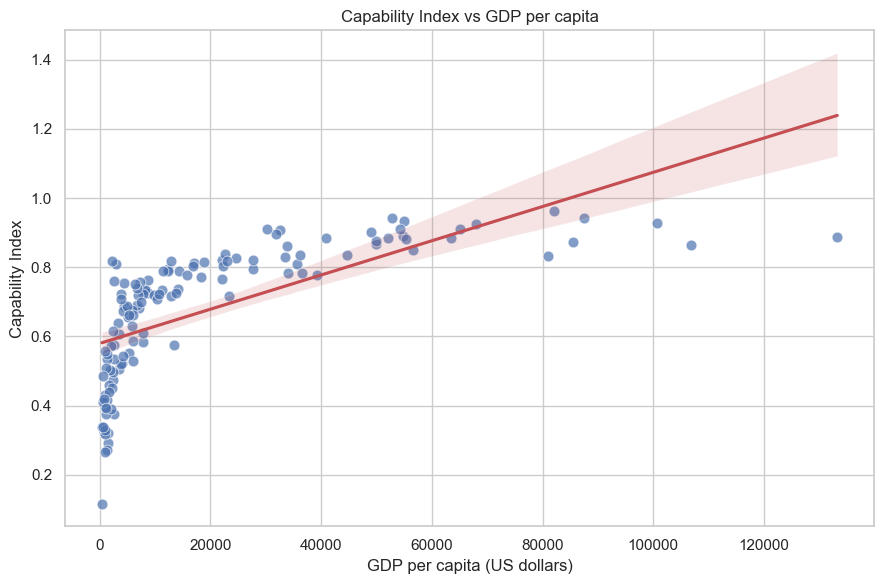

In [4]:
corr_gdp = df["capability_index"].corr(df["gdp_per_capita"])
print("Correlation, Capability Index vs GDP:", round(corr_gdp, 2))

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="gdp_per_capita", y="capability_index",
                color="#4c72b0", s=60, alpha=0.7)
sns.regplot(data=df, x="gdp_per_capita", y="capability_index",
            scatter=False, color="#c44e52")

plt.title("Capability Index vs GDP per capita")
plt.xlabel("GDP per capita (US dollars)")
plt.ylabel("Capability Index")
plt.tight_layout()
plt.show()

**Capability Index vs GDP:**

The correlation is 0.67. That is a clear link, richer countries do tend to have
stronger capabilities, but it is far from perfect (a perfect link would be 1.0). So
money explains part of capabilities, not all.

The chart shows the same curved shape we keep seeing. On the left, where countries
are poor, capability rises fast. On the right, where countries are rich, it flattens
out, extra money adds little more.

The most telling part is the left side. At roughly the same low GDP, the dots spread
from very low to fairly high capability. So among countries with similar (low)
income, some still manage much stronger education, health, freedom and support than
others. Money does not decide it for them.

In plain words: capabilities and income move together, but a 0.67 link with a
flattening curve means human development is clearly about more than money, which is
exactly Sen's argument.

## 5. Compare: Capability Index vs HDI and vs Happiness

We expect the index to agree more with HDI and happiness than with GDP, because all
three are about human well-being rather than money. We plot both side by side and
check the correlation numbers.

Capability Index vs HDI: 0.94
Capability Index vs Happiness: 0.86


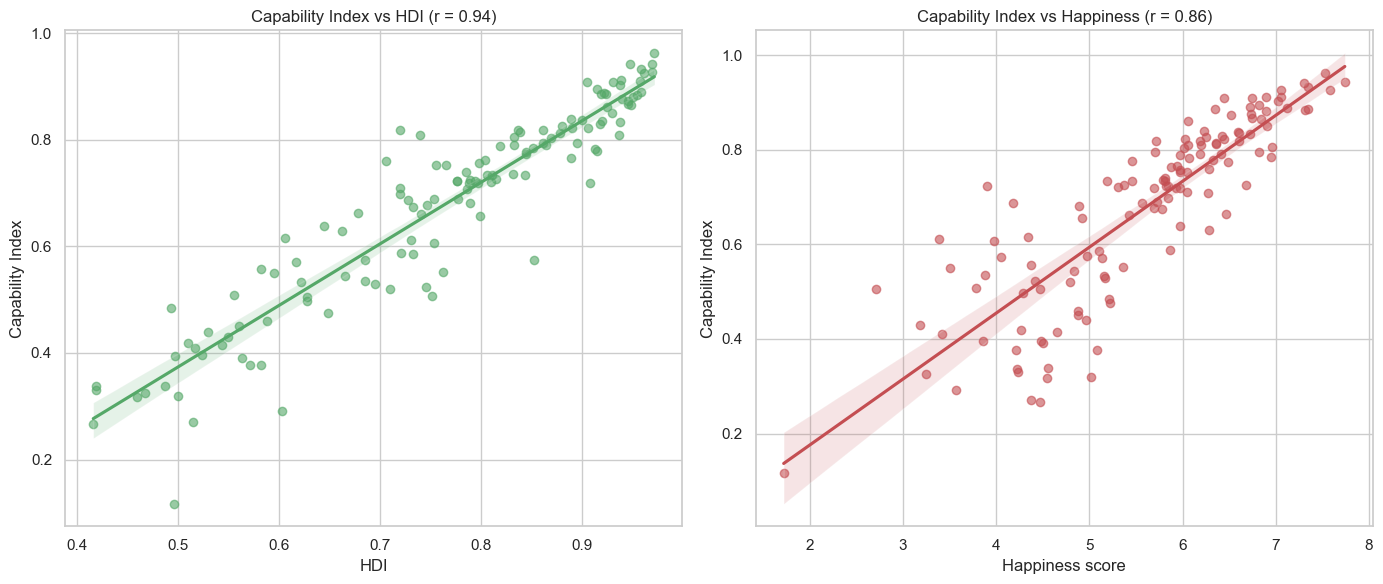

In [5]:
corr_hdi = df["capability_index"].corr(df["hdi"])
corr_happy = df["capability_index"].corr(df["happiness_score"])
print("Capability Index vs HDI:", round(corr_hdi, 2))
print("Capability Index vs Happiness:", round(corr_happy, 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.regplot(data=df, x="hdi", y="capability_index",
            ax=axes[0], color="#55a868",
            scatter_kws={"alpha": 0.6})
axes[0].set_title(f"Capability Index vs HDI (r = {round(corr_hdi, 2)})")
axes[0].set_xlabel("HDI")
axes[0].set_ylabel("Capability Index")

sns.regplot(data=df, x="happiness_score", y="capability_index",
            ax=axes[1], color="#c44e52",
            scatter_kws={"alpha": 0.6})
axes[1].set_title(f"Capability Index vs Happiness (r = {round(corr_happy, 2)})")
axes[1].set_xlabel("Happiness score")
axes[1].set_ylabel("Capability Index")

plt.tight_layout()
plt.show()

**Capability Index vs HDI and Happiness:**

This is the most important part of the whole project. Let us go very slowly and
simply.

### First, a quick reminder

We made our own score called the Capability Index. We built it from four things
about people:
- Education (how many years they study)
- Health (how long they live)
- Freedom (can they make their own choices)
- Social support (do they have people to rely on)

We did NOT use money (GDP) to build it. This was on purpose.

### Now the test

We want to see: is our score more like "money", or more like "human well-being"?

So we compared our score with three other things. We use a number from 0 to 1.
- A number near 1 means "very similar".
- A number near 0 means "not similar".

Here are the three results:
- Capability Index vs GDP (money): 0.67
- Capability Index vs Happiness: 0.86
- Capability Index vs HDI (development): 0.94

### What this means (the simple version)

Look at which number is biggest and which is smallest.

- Most similar to HDI (0.94). HDI is also about people (long life, education, decent
  living). Our score is about people too. So they match almost perfectly. Makes sense.
- Quite similar to Happiness (0.86). When people can study, stay healthy, and feel
  free, they are usually happier. So the match is strong, but not perfect, because
  happiness also depends on other things.
- Least similar to GDP (0.67). GDP is only money. We did not use money to build our
  score. So it matches money the least.

In one line: when you measure a country by what its people can actually do, you get
something that looks a lot like HDI and happiness, and much less like just money.

### The two charts in simple words

- Left chart (our score vs HDI): the dots almost make a straight line going up. This
  means the two move together very closely. They are telling almost the same story.
- Right chart (our score vs Happiness): the dots also go up, but they are more
  spread out. So our score is linked to happiness, but happiness also depends on
  other things our score cannot measure, like feelings, culture, and what is
  happening in a person's life.

### The big takeaway

This is the main message of the whole project, in one place:

If money alone decided how developed a country is, then our money-free score should
NOT match HDI and happiness so well. But it does match them well. This tells us that
real development is mostly about people's lives and abilities, not just about money.

### One honest point

Our Capability Index is just an experiment. It is not better than HDI, and it is not
meant to replace it. It is a simple way to show Amartya Sen's idea using our own
data: money is important, but it is not the full story of development.